In [14]:
import numpy as np
import scipy 
from scipy import linalg
from scipy.sparse import diags, linalg
import matplotlib.pylab as plt
from matplotlib import cm
import time

In [15]:
# Função para plotar os curvas de nível constante de temperatura
def PlotaMembrane(N1,N2,L,L2,W):
    x = np.linspace(0, L1, N1)
    y = np.linspace(0, L2, N2)
    X,Y=np.meshgrid(x,y)
    Z = np.copy(W)
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.set(xlabel='x', ylabel='y', title='Deslocamento vertical')
    im = ax.contourf(X, Y, Z, 20)
    im2 = ax.contour(X, Y, Z, 20, linewidths=0.25, colors='k')
    fig.colorbar(im, ax=ax)
    plt.show()
    
def PlotaSurface(N1,N2,L1,L2,W):
    x = np.linspace(0, L1, N1)
    y = np.linspace(0, L2, N2)
    X,Y=np.meshgrid(x,y)
    Z = np.copy(W)
    ax = plt.axes(projection ='3d')
    ax.plot_surface(X, Y, Z,cmap='viridis', edgecolor='none')
    ax.set(xlabel='x', ylabel='y', title='Deslocamento vertical')
    ax.set_zlim(-1.01, 1.01)
    ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,linewidth=0, antialiased=False)
    

### Exercício 1

[0.11709713935852051, 2.2144181728363037, 8.726223468780518, 33.47210669517517]


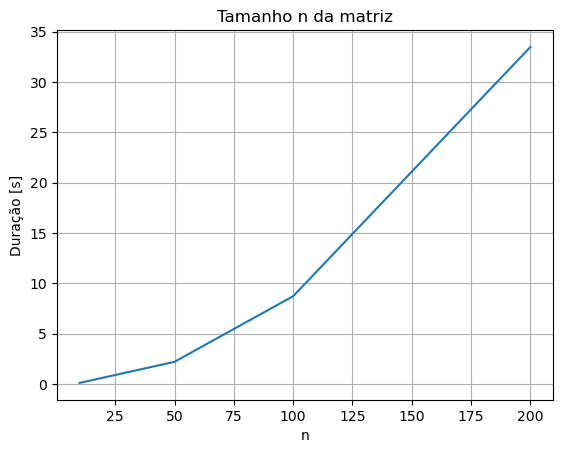

In [20]:
import numpy as np
import scipy 
from scipy import linalg
import time
import random
import matplotlib.pyplot as plt

def m_randsim(n):
    A = np.zeros(shape=(n,n))
    for i in range(n):
        for j in range(0,i+1):
            a = random.randint(0,100)
            A[i,j] = a
            A[j,i] = a
    return A

def max_ndiag(A):
    tam = len(A)
    maior = A[0,0]
    for i in range(tam):
        for j in range(tam):
            if(i!=j and A[i,j]>maior):
                maior = A[i,j]
    return maior

def Francis(A, MAX_INT, TOL):
    k = 1
    Ak = A.copy()
    V = np.identity(len(A[:,0]))
    e = TOL +1
    
    while(e > TOL and k < MAX_INT):
        Q, R = scipy.linalg.qr(Ak)
        Ak = R @ Q
        V = V @ Q
        e = max_ndiag(Ak)
        k += 1
    return Ak, V

tamanhos = [10, 50, 100, 200]
duracao = []
for n in tamanhos:
    A = m_randsim(n)
    ti = time.time()
    Ak, V = Francis(A, 2000, 10**-6)
    tempo = time.time() - ti
    duracao.append(tempo)

print(duracao)
plt.plot(tamanhos, duracao)
plt.grid()
plt.xlabel('n')
plt.ylabel('Duração [s]')
plt.title('Tamanho n da matriz')
plt.show()

### Exercício 2

In [29]:
import numpy as np
import scipy.linalg
import random


def m_densa(A, n):
    Ak = A.copy()
    for i in range(n):
        V = np.random.rand(n, n)
        V, _ = np.linalg.qr(V)         # Matriz ortogonal (V^T = V^-1)
        Ak = V @ A @ np.transpose(V)
    return Ak

def Francis(A, MAX_INT, TOL):
    k = 1
    Ak = A.copy()
    V = np.identity(len(A[:,0]))
    e = TOL +1
    
    while(e > TOL and k < MAX_INT):
        Q, R = scipy.linalg.qr(Ak)
        Ak = R @ Q
        V = V @ Q
        e = max_ndiag(Ak)
        k += 1
    return Ak, V

tamanhos = [10, 50, 100, 200]
for n in tamanhos:
    A = np.zeros(shape=(n, n))
    autovalores = np.arange(1, n + 1)
    A = np.diag(autovalores)
    #print("Matriz A:\n", A)
    
    A_densa = m_densa(A, n)
    #print("Matriz densa:\n", A_densa)
    
    Ak, V = Francis(A, 1, 10 ** -5)
    print("\nAutovalores por Francis:\n", np.diag(Ak))

    w, v = scipy.linalg.eigh(A_densa)
    print("\nAutovalores por Eigh:\n", w)



Autovalores por Francis:
 [ 1  2  3  4  5  6  7  8  9 10]

Autovalores por Eigh:
 [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]

Autovalores por Francis:
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]

Autovalores por Eigh:
 [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]

Autovalores por Francis:
 [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]

Autovalores por Eigh:
 [  1.   

### Exercício 5

[ 4.74059987  7.54800032  7.54800032 10.09901017 10.11520836 10.86004988
 12.54187416 12.54187416 13.78151296 13.78151296 14.86235245 14.9313353
 16.50354303 16.50783852 16.96438528 17.19160454 17.19160454 19.10367896
 19.10367896 19.34904512]


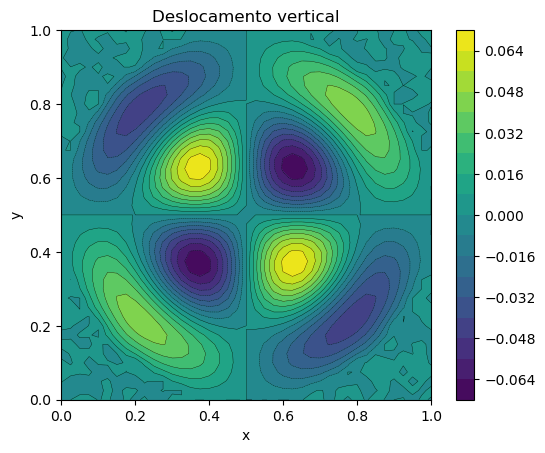

In [30]:
def ij2n (i, j, N):
    return i + j*N

def BuildMatrizesEigenCircular(N1, N2, sigma, rho, e, delta, R):
    nunk = N1*N2
    
    # K é uma matriz esparsa da rigidez da membrana
    d1 = 4.0*np.ones(nunk)
    d2 = -np.ones(nunk-1)
    d3 = -np.ones(nunk-N1)
    K = (sigma/delta**2)* diags([d3, d2, d1, d2, d3], [-N1, -1, 0, 1, N1], format='csr')

    # Para não ter autovalor = 1 artificial, são multiplicados por um coeficiente
    # Como os autovalores são grandes, eles serão descartados
    big_number = 10000
    Iden = big_number* scipy.sparse.identity(nunk, format='csr')

    meio_x = int((N1-1)/2)
    meio_y = int((N2-1)/2)
    
    ''' Na borda, a inércia dos pontos da borda será muito grande 
    (--> infinita) cálculo não vai misturar os autovalores reais 
    (as frequências) com os autovalores artificiais muito grandes'''
    
    for i in range(N1):
        for j in range(N2):
            # Delta é a distância entre dois vértices da grade
            dist = (((i - meio_x) * delta) ** 2 + ((j - meio_y) * delta) ** 2) ** 0.5
            if dist >= R:
                Ic = ij2n(i, j, N1)
                K[Ic,:], K[:,Ic] = Iden[Ic,:], Iden[:,Ic]

    # M é múltipla da matriz identidade (matriz das massas)
    M = rho*e*scipy.sparse.identity(nunk, format='csr')
    
    return K, M   

# Tamanho da grade
N1 = 41
N2 = 41
L1 = 1
L2 = 1

# Distancia entre pontos [L1/(N1-1) deve ser igual a L2/(N2-1)]
delta = L1 / (N1-1) 

sigma = 1    # Tensão da membrana
rho = 1      # Densidade do material
e = 1        # Espessura da membrana

R = 0.5      # Raio da membrana

# Aplicar restrições nas bordas
K, M = BuildMatrizesEigenCircular(N1, N2, sigma, rho, e, delta, R)
#print(K.todense(), "\n\n", M.todense())
#plt.spy(K, markersize=0.75)

# Calcular modos de oscilação
# Método tipo Francis: Todos os autovalores e autovetores (não trabalha com esparsas)
#Lam, Q = scipy.linalg.eigh(K.todense(), M.todense())

# Método tipo potencias: Apenas os modos fundamentais (trabalha com esparsas!)
Lam, Q = scipy.sparse.linalg.eigsh(K, k=20, M=M, which='SM')

omegas = np.sqrt(Lam)
print(omegas)


# Plotar
k = 12
mode = Q[:,k] 

Wplot = mode.reshape(N2,N1)
PlotaMembrane(N1,N2,L1,L2,Wplot)

### Exercício 6

[[10000.     0.     0. ...     0.     0.     0.]
 [    0. 10000.     0. ...     0.     0.     0.]
 [    0.     0. 10000. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ... 10000.     0.     0.]
 [    0.     0.     0. ...     0. 10000.     0.]
 [    0.     0.     0. ...     0.     0. 10000.]] 

 [[1.75       0.         0.         ... 0.         0.         0.        ]
 [0.         1.71329239 0.         ... 0.         0.         0.        ]
 [0.         0.         1.60676275 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.39323725 0.         0.        ]
 [0.         0.         0.         ... 0.         0.28670761 0.        ]
 [0.         0.         0.         ... 0.         0.         0.25      ]]
[ 6.97142565  8.74975926 10.78130683 13.14324426 13.83493327 13.91737981
 15.15994631 17.2962674  17.29969793 17.95270124 18.72396968 20.05328436
 20.31183273 21.28548055 21.66652814 22.50166221 23.00493194 23.28043989
 24.12482578 24.83840886]


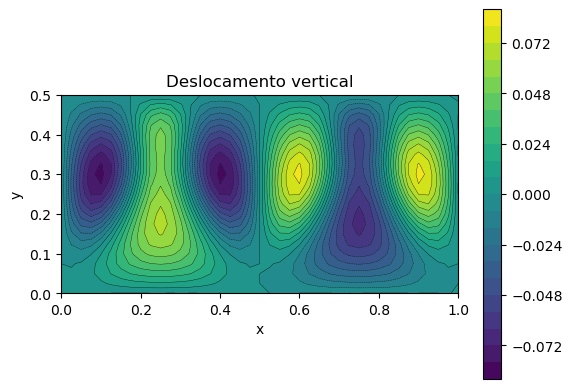

In [32]:
def ij2n (i, j, N):
    return i + j*N

def BuildMatrizesEigen(N1, N2, sigma, e, delta, R):
    nunk = N1*N2

    # K é uma matriz esparsa da rigidez da membrana
    d1 = 4.0*np.ones(nunk)
    d2 = -np.ones(nunk-1)
    d3 = -np.ones(nunk-N1)
    K = (sigma/delta**2)* diags([d3, d2, d1, d2, d3], [-N1, -1, 0, 1, N1], format='csr')
    
    # Para não ter autovalor = 1 artificial, são multiplicados por um coeficiente
    # Como os autovalores são grandes, eles serão descartados
    big_number = 10000
    Iden = big_number* scipy.sparse.identity(nunk, format='csr')

    ''' Na borda, a inércia dos pontos da borda será muito grande 
    (--> infinita) cálculo não vai misturar os autovalores reais 
    (as frequências) com os autovalores artificiais muito grandes'''
    
    # Lados verticais
    for k in range(0,N2):
        Ic = ij2n(0,k,N1) # Left
        K[Ic,:], K[:,Ic] = Iden[Ic,:], Iden[:,Ic]

        Ic = ij2n(N1-1,k,N1) # Right
        K[Ic,:], K[:,Ic] = Iden[Ic,:], Iden[:,Ic]
        
    # Lados horizontais
    for k in range(0,N1):
        Ic = ij2n(k,0,N1) # Bottom
        K[Ic,:], K[:,Ic] = Iden[Ic,:], Iden[:,Ic]

        Ic = ij2n(k,N2-1,N1) # Top
        K[Ic,:], K[:,Ic] = Iden[Ic,:], Iden[:,Ic]
        
    # Densidade variável (depende da posição na grade)
    M = scipy.sparse.identity(nunk, format='csr')
    for i in range(N1):
        for j in range(N2):
            # (x,y) dependem do tamanho da grade
            x = i / (N1 - 1)
            y = (j/(N2 - 1)) * 0.5
            
            rho =  1 + 0.75 *np.cos(4*np.pi*x) *np.cos(2*np.pi*y)
            Ic = ij2n(i,j,N1) 
            M[Ic,Ic] = rho*e    # Massa do ponto material
    
    return K, M   

# Tamanho da grade
N1 = 41
N2 = 21
L1 = 1.0
L2 = 0.5
# Distancia entre pontos: Cuidado para que L1/(N1-1) seja igual a L2/(N2-1)
delta = L1 / (N1-1) 

sigma = 1     # Tensão da membrana
e = 1         # Espessura da membrana

# Aplicar restrições nas bordas
K, M = BuildMatrizesEigen(N1, N2, sigma, e, delta, R)
print(K.todense(), "\n\n", M.todense())
#plt.spy(K, markersize=0.75)

# Calcular modos de oscilação
# Método tipo Francis: Todos os autovalores e autovetores (não trabalha com esparsas)
#Lam, Q = scipy.linalg.eigh(K.todense(), M.todense())

# Método tipo potencias: Apenas os modos fundamentais (trabalha com esparsas!)
Lam, Q = scipy.sparse.linalg.eigsh(K, k=20, M=M, which='SM')

omegas = np.sqrt(Lam)
print(omegas)

# Plotar 
k = 12
mode = Q[:,k] 

Wplot = mode.reshape(N2,N1)
PlotaMembrane(N1,N2,L1,L2,Wplot)